**Датасет:** https://www.kaggle.com/datasets/uciml/autompg-dataset

# Лабораторная работа №1. Линейная регрессия и факторный анализ
### Отчет по практическому заданию курса «Машинное обучение»

### 1) Введение. Краткое описание целей и задач работы

- **Цель работы:** изучение теоретических основ линейной регрессии, построение моделей множественной линейной регрессии, гребневой регрессии (Ridge) и регрессии лассо (Lasso), обучение на реальных данных и сравнительная оценка качества до и после устранения мультиколлинеарности методом главных компонент (PCA).
- **Постановка задачи:**
  1. Загрузить набор данных об автомобилях `Auto MPG` (`data/auto_mpg.csv`).
  2. Провести первичный разведочный анализ (EDA), визуализировать распределения признаков и целевой переменной.
  3. Выполнить предобработку: удалить пропуски, закодировать категориальные переменные, разделить выборку 80/20 и стандартизировать признаки.
  4. Построить матрицу корреляций и оценить мультиколлинеарность коэффициентом VIF.
  5. Обучить линейную, Ridge и Lasso регрессии с 5-фолдовой кросс-валидацией и оценить RMSE, R² и MAPE.
  6. Снизить размерность методом PCA, построить график каменистой осыпи и исследовать факторные нагрузки.
  7. Повторить обучение на главных компонентах и сопоставить метрики с моделями на исходных признаках.
- **Датасет:** характеристики легковых автомобилей 1970–1982 годов. Целевая переменная — топливная экономичность `mpg` (мили на галлон). Чем выше значение, тем экономичнее автомобиль.


### 2) Описание датасета

Набор Auto MPG опубликован в репозитории UCI и на [Kaggle](https://www.kaggle.com/datasets/uciml/autompg-dataset). Это лабораторные и каталожные характеристики автомобилей: число цилиндров, объём двигателя, мощность, масса, разгон, год модели и страна происхождения.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

RU_NAMES = {
    "mpg": "Расход топлива (mpg)",
    "cylinders": "Число цилиндров",
    "displacement": "Объём двигателя",
    "horsepower": "Мощность",
    "weight": "Масса",
    "acceleration": "Разгон",
    "model_year": "Год выпуска",
    "origin": "Страна",
    "name": "Модель",
}

df = pd.read_csv("data/auto_mpg.csv")
df_ru = df.rename(columns=RU_NAMES)
df_ru["Страна"] = df_ru["Страна"].map({"usa": "США", "japan": "Япония", "europe": "Европа"})

print("=" * 80)
print(f"Размерность датасета: {df_ru.shape[0]} строк, {df_ru.shape[1]} признаков")
print("=" * 80)
print("\nПервые 5 строк датасета:")
print(df_ru.head().to_string())

print("\nПроверка пропущенных значений:")
print(df_ru.isnull().sum().to_string())

duplicates_count = int(df_ru.duplicated().sum())
print(f"\nКоличество повторяющихся строк (дубликатов): {duplicates_count}")
print(f"Пропусков в мощности: {int(df_ru['Мощность'].isna().sum())}")


Размерность датасета: 398 строк, 9 признаков

Первые 5 строк датасета:
   Расход топлива (mpg)  Число цилиндров  Объём двигателя  Мощность  Масса  Разгон  Год выпуска Страна                     Модель
0                  18.0                8            307.0     130.0   3504    12.0           70    США  chevrolet chevelle malibu
1                  15.0                8            350.0     165.0   3693    11.5           70    США          buick skylark 320
2                  18.0                8            318.0     150.0   3436    11.0           70    США         plymouth satellite
3                  16.0                8            304.0     150.0   3433    12.0           70    США              amc rebel sst
4                  17.0                8            302.0     140.0   3449    10.5           70    США                ford torino

Проверка пропущенных значений:
Расход топлива (mpg)    0
Число цилиндров         0
Объём двигателя         0
Мощность                6
Масса        

### Пояснение к первичному анализу данных

- **Объем выборки:** исходный файл содержит 398 автомобилей и 9 столбцов. Целевая переменная — `Расход топлива (mpg)`. Имя модели (`Модель`) в регрессию не входит: это текстовая метка с сотнями уникальных значений.
- **Пропуски:** незаполнена только мощность — 6 строк. Остальные поля полные. Пропуски удаляются, без подстановки среднего: шесть наблюдений не меняют структуру выборки, а выдуманная мощность исказила бы связь с расходом.
- **Дубликаты:** повторяющихся строк нет.
- **Структура признаков:** 6 числовых характеристик конструкции (`Число цилиндров`, `Объём двигателя`, `Мощность`, `Масса`, `Разгон`, `Год выпуска`), 1 категориальный атрибут (`Страна`) и 1 текстовое имя модели.


In [2]:
df_work = df_ru.drop(columns=["Модель"]).dropna().reset_index(drop=True)
print(f"Размерность после удаления пропусков: {df_work.shape[0]} строк")

numeric_cols = [
    "Расход топлива (mpg)",
    "Число цилиндров",
    "Объём двигателя",
    "Мощность",
    "Масса",
    "Разгон",
    "Год выпуска",
]
stats_df = df_work[numeric_cols].describe().T
stats_df["Медиана"] = df_work[numeric_cols].median()
stats_df["Мода"] = [df_work[col].mode()[0] for col in numeric_cols]
stats_df["Межквартильный размах (IQR)"] = stats_df["75%"] - stats_df["25%"]
stats_df["Коэффициент асимметрии"] = df_work[numeric_cols].skew()
stats_df = stats_df.rename(columns={
    "mean": "Среднее",
    "std": "Станд. откл.",
    "min": "Минимум",
    "max": "Максимум",
})

print("=" * 95)
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА ЧИСЛОВЫХ ПЕРЕМЕННЫХ:")
print("=" * 95)
print(stats_df[[
    "Среднее", "Станд. откл.", "Медиана", "Мода",
    "Межквартильный размах (IQR)", "Минимум", "Максимум", "Коэффициент асимметрии",
]].round(2).to_string())

print("\n" + "=" * 95)
print("ЧАСТОТНЫЙ АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПЕРЕМЕННЫХ:")
print("=" * 95)
for col in ["Страна", "Число цилиндров"]:
    counts = df_work[col].value_counts()
    percentages = df_work[col].value_counts(normalize=True) * 100
    cat_summary = pd.DataFrame({
        "Абсолютная частота": counts,
        "Относительная доля (%)": percentages.round(2),
    })
    print(f"\nПризнак: {col}")
    print(cat_summary.to_string())


Размерность после удаления пропусков: 392 строк
ОПИСАТЕЛЬНАЯ СТАТИСТИКА ЧИСЛОВЫХ ПЕРЕМЕННЫХ:
                      Среднее  Станд. откл.  Медиана    Мода  Межквартильный размах (IQR)  Минимум  Максимум  Коэффициент асимметрии
Расход топлива (mpg)    23.45          7.81    22.75    13.0                        12.00      9.0      46.6                    0.46
Число цилиндров          5.47          1.71     4.00     4.0                         4.00      3.0       8.0                    0.51
Объём двигателя        194.41        104.64   151.00    97.0                       170.75     68.0     455.0                    0.70
Мощность               104.47         38.49    93.50   150.0                        51.00     46.0     230.0                    1.09
Масса                 2977.58        849.40  2803.50  1985.0                      1389.50   1613.0    5140.0                    0.52
Разгон                  15.54          2.76    15.50    14.5                         3.25      8.0      24.8 

### Пояснение к описательным статистикам

- **Целевая переменная:** средний расход 23,45 mpg, медиана 22,75. Распределение умеренно скошено вправо (асимметрия 0,46), диапазон от 9,0 до 46,6 mpg.
- **Конструкция:** типичный автомобиль выборки — 4 цилиндра, масса около 2800 фунтов, мощность около 93–105 л.с. Объём двигателя и мощность имеют правый хвост: в выборке есть тяжёлые американские V8.
- **Страна:** 62,5% наблюдений — автомобили США, 20,2% — Япония, 17,3% — Европа. Американские машины в среднем заметно менее экономичны.
- **Год выпуска:** с 1970 по 1982 (в файле записаны как 70–82). Это период топливного кризиса, поэтому год должен быть связан с ростом экономичности.


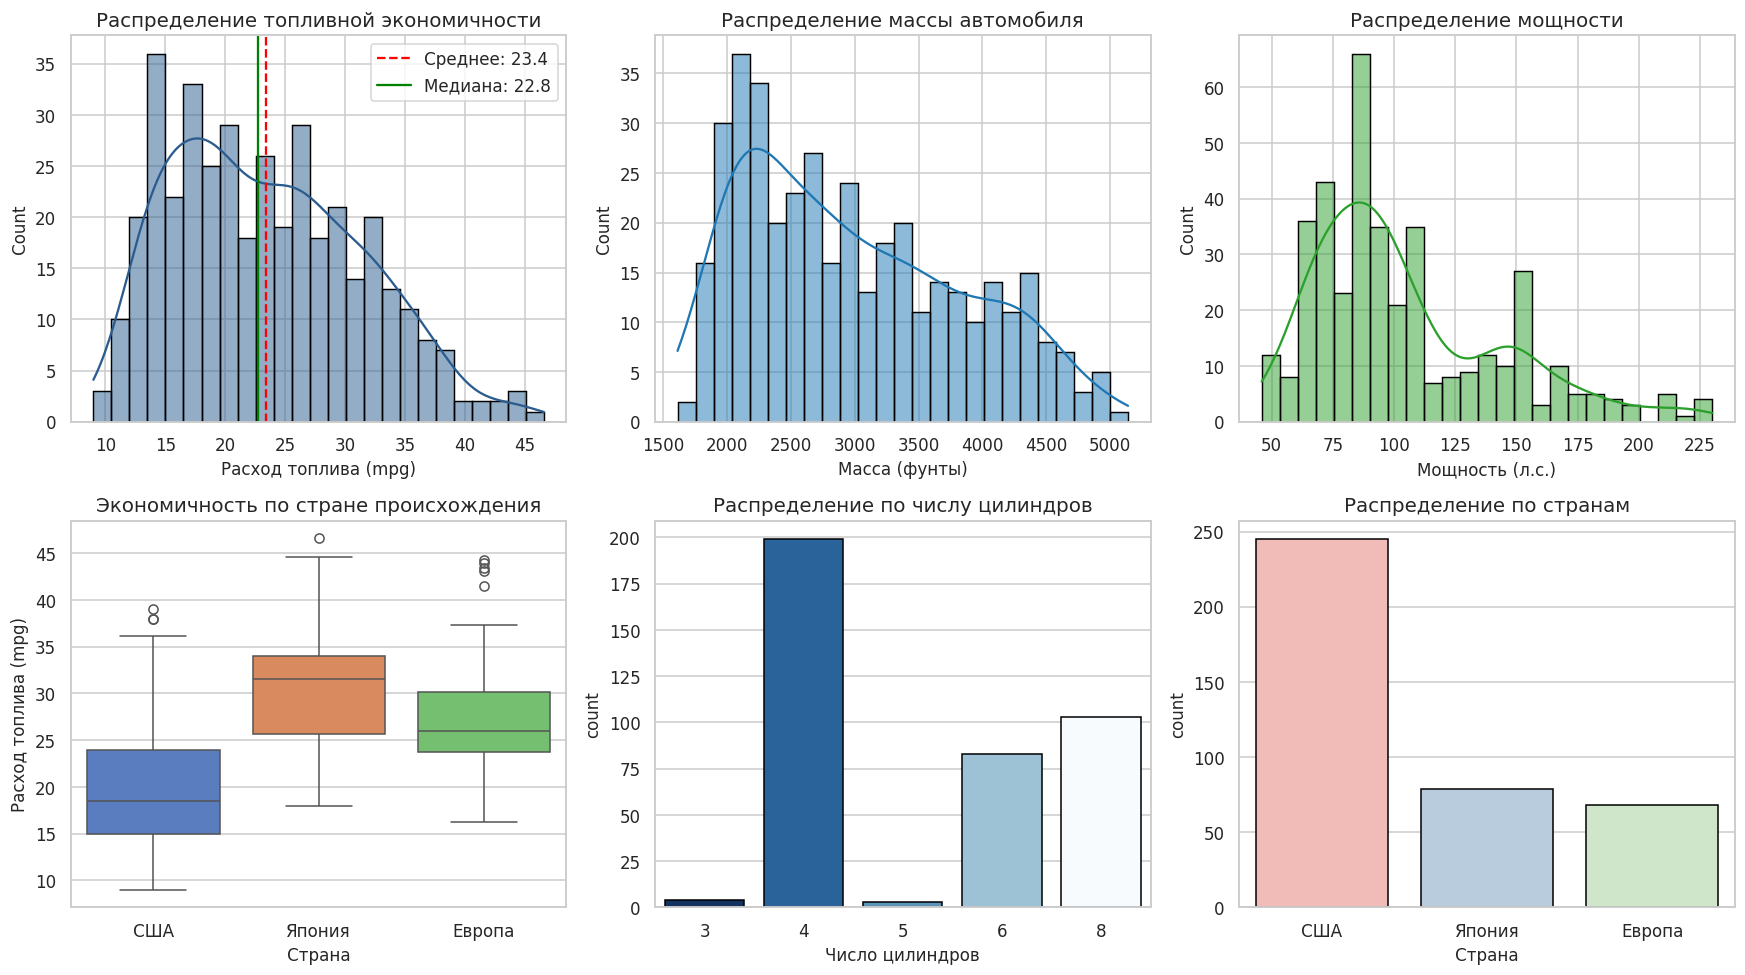

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(df_work["Расход топлива (mpg)"], kde=True, ax=axes[0, 0], color="#2b5c8f", bins=25, edgecolor="black")
axes[0, 0].axvline(df_work["Расход топлива (mpg)"].mean(), color="red", linestyle="--",
                   label=f"Среднее: {df_work['Расход топлива (mpg)'].mean():.1f}")
axes[0, 0].axvline(df_work["Расход топлива (mpg)"].median(), color="green", linestyle="-",
                   label=f"Медиана: {df_work['Расход топлива (mpg)'].median():.1f}")
axes[0, 0].set_title("Распределение топливной экономичности")
axes[0, 0].set_xlabel("Расход топлива (mpg)")
axes[0, 0].legend()

sns.histplot(df_work["Масса"], kde=True, ax=axes[0, 1], color="#1f77b4", bins=25, edgecolor="black")
axes[0, 1].set_title("Распределение массы автомобиля")
axes[0, 1].set_xlabel("Масса (фунты)")

sns.histplot(df_work["Мощность"], kde=True, ax=axes[0, 2], color="#2ca02c", bins=25, edgecolor="black")
axes[0, 2].set_title("Распределение мощности")
axes[0, 2].set_xlabel("Мощность (л.с.)")

sns.boxplot(data=df_work, x="Страна", y="Расход топлива (mpg)", ax=axes[1, 0], hue="Страна", legend=False)
axes[1, 0].set_title("Экономичность по стране происхождения")

sns.countplot(data=df_work, x="Число цилиндров", ax=axes[1, 1], hue="Число цилиндров", palette="Blues_r", edgecolor="black", legend=False)
axes[1, 1].set_title("Распределение по числу цилиндров")

sns.countplot(data=df_work, x="Страна", ax=axes[1, 2], hue="Страна", palette="Pastel1", edgecolor="black", legend=False)
axes[1, 2].set_title("Распределение по странам")

plt.tight_layout()
plt.show()


### Пояснение к графикам распределений

- Расход топлива унимодален, без разрыва на отдельные классы: линейная регрессия по этой цели уместна.
- Масса и мощность скошены вправо. Масштабы несопоставимы (фунты, литры, лошадиные силы, годы), поэтому перед Ridge, Lasso и PCA обязательна стандартизация.
- Японские и европейские автомобили экономичнее американских. Число цилиндров дискретное: в выборке преобладают 4- и 8-цилиндровые машины.


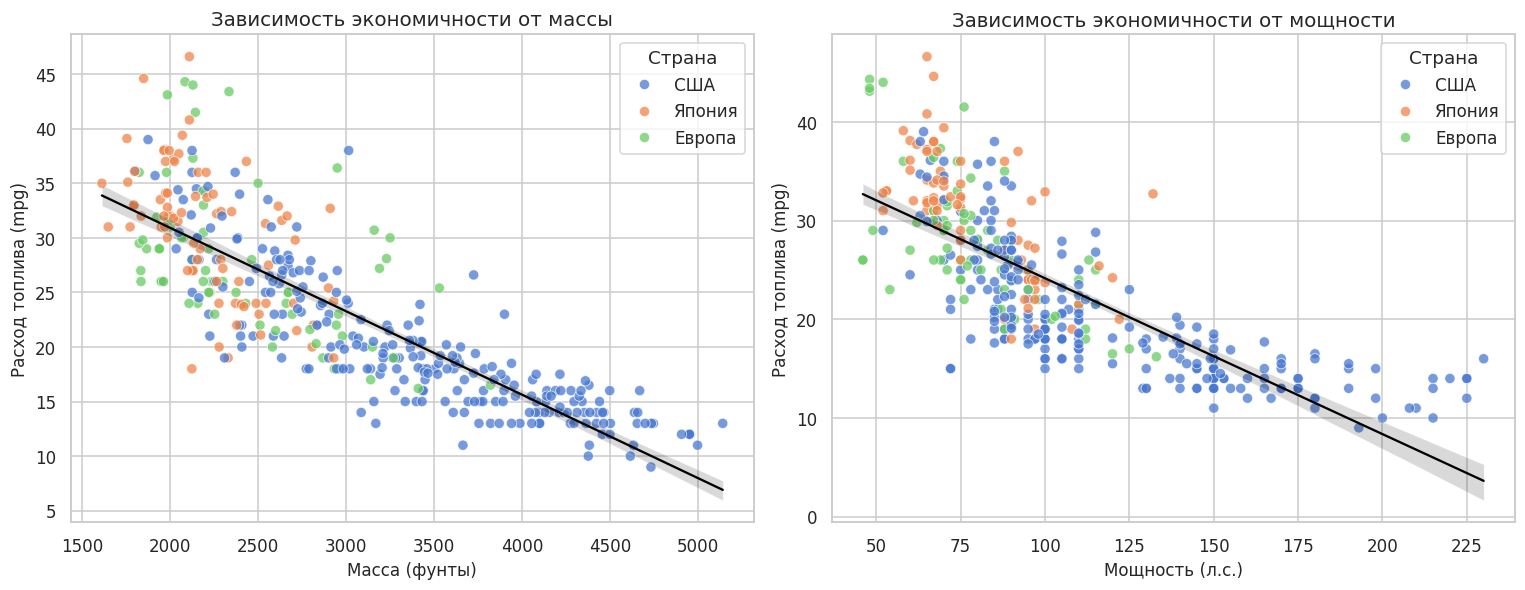

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.scatterplot(
    data=df_work, x="Масса", y="Расход топлива (mpg)", hue="Страна",
    alpha=0.75, s=45, ax=axes[0],
)
sns.regplot(
    data=df_work, x="Масса", y="Расход топлива (mpg)",
    scatter=False, ax=axes[0], color="black", line_kws={"linewidth": 1.5},
)
axes[0].set_title("Зависимость экономичности от массы")
axes[0].set_xlabel("Масса (фунты)")
axes[0].set_ylabel("Расход топлива (mpg)")

sns.scatterplot(
    data=df_work, x="Мощность", y="Расход топлива (mpg)", hue="Страна",
    alpha=0.75, s=45, ax=axes[1],
)
sns.regplot(
    data=df_work, x="Мощность", y="Расход топлива (mpg)",
    scatter=False, ax=axes[1], color="black", line_kws={"linewidth": 1.5},
)
axes[1].set_title("Зависимость экономичности от мощности")
axes[1].set_xlabel("Мощность (л.с.)")
axes[1].set_ylabel("Расход топлива (mpg)")

plt.tight_layout()
plt.show()


### Пояснение к диаграммам рассеяния

- Чем тяжелее автомобиль и чем выше мощность, тем ниже mpg. Связь отрицательная и достаточно тесная, линейный тренд читается явно.
- Американские точки сосредоточены в правой части обоих графиков (тяжёлые и мощные), японские — в левой. Страна частично дублирует конструкцию, но не заменяет её полностью.


### 3) Подготовка данных

Категория `Страна` кодируется бинарными индикаторами (`drop_first=True`). Базовый уровень — Европа. Имя модели уже исключено. Признаки стандартизируются по обучающей выборке.


In [5]:
df_encoded = pd.get_dummies(df_work, columns=["Страна"], drop_first=True, dtype=int)
df_encoded = df_encoded.rename(columns={
    "Страна_США": "Страна (США)",
    "Страна_Япония": "Страна (Япония)",
})

TARGET = "Расход топлива (mpg)"
X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names)

print(f"Размерность после кодирования: {df_encoded.shape}")
print(f"Обучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")
print("Признаки после кодирования:")
for name in feature_names:
    print(f"  - {name}")
print(f"\nСреднее mpg, train / test: {y_train.mean():.2f} / {y_test.mean():.2f}")
print(f"Ст. отклонение mpg, train / test: {y_train.std():.2f} / {y_test.std():.2f}")


Размерность после кодирования: (392, 9)
Обучающая выборка: 313 объектов
Тестовая выборка: 79 объектов
Признаки после кодирования:
  - Число цилиндров
  - Объём двигателя
  - Мощность
  - Масса
  - Разгон
  - Год выпуска
  - Страна (США)
  - Страна (Япония)

Среднее mpg, train / test: 23.60 / 22.84
Ст. отклонение mpg, train / test: 7.96 / 7.19


### Пояснение к предобработке

- После удаления 6 строк с пропуском мощности рабочая выборка — **392 автомобиля**. Кодирование страны добавляет два индикатора, всего 8 предикторов.
- Разбиение 80/20: 313 объектов на обучение и 79 на тест, `random_state=42`.
- Стандартизация обязательна: иначе штраф Ridge/Lasso и главные компоненты определятся массой в тысячах фунтов, а не связью с расходом. Среднее и масштаб считаются только по обучающей выборке.


### 4) Ход работы

#### Корреляционная матрица


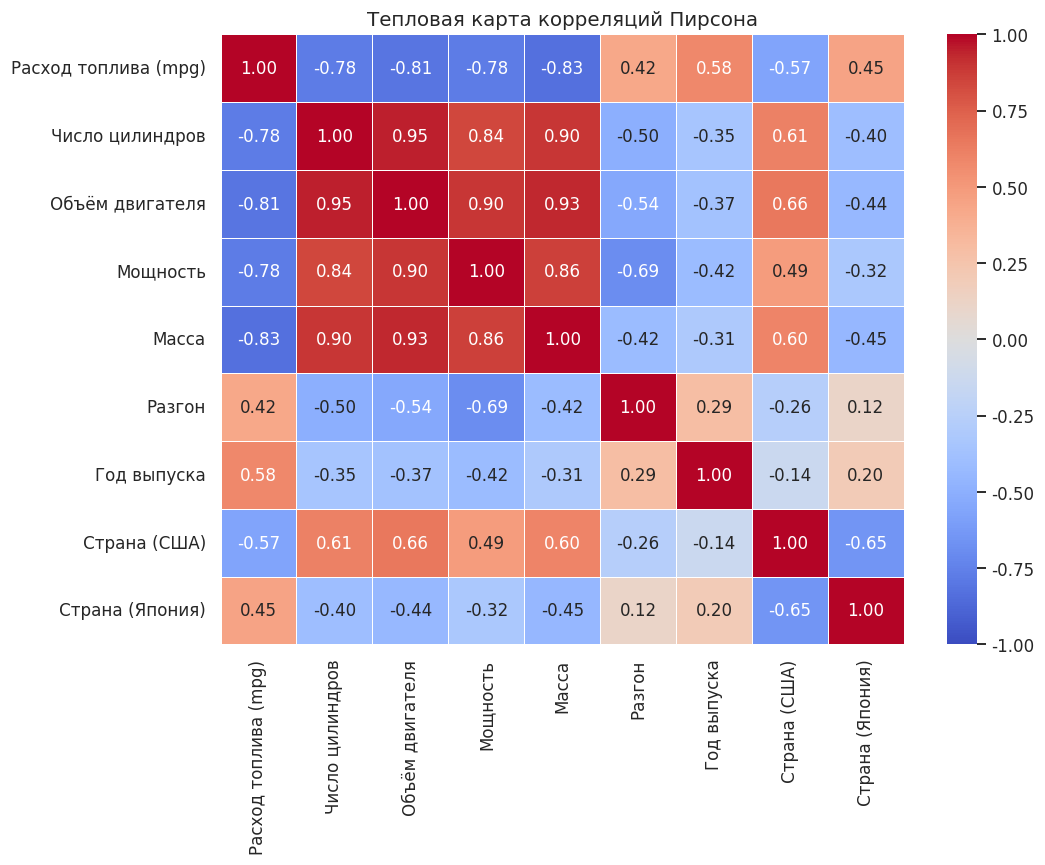

Корреляция признаков с целевой переменной:
Масса             -0.832
Объём двигателя   -0.805
Мощность          -0.778
Число цилиндров   -0.778
Год выпуска        0.581
Страна (США)      -0.565
Страна (Япония)    0.451
Разгон             0.423


In [6]:
corr_matrix = df_encoded.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Тепловая карта корреляций Пирсона")
plt.tight_layout()
plt.show()

target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
print("Корреляция признаков с целевой переменной:")
print(target_corr.round(3).to_string())


### Пояснение к корреляциям

- С расходом топлива сильнее всего связаны масса (\(r = -0,83\)), объём двигателя (\(-0,81\)), мощность и число цилиндров (оба около \(-0,78\)). Год выпуска связан положительно (\(0,58\)): более новые машины экономичнее.
- Между собой объём, цилиндры, мощность и масса коррелируют на 0,84–0,95. Это один конструктивный блок «большой двигатель — тяжёлый автомобиль», а не четыре независимых фактора.
- Индикатор США отрицательно связан с mpg (\(-0,57\)), индикатор Японии — положительно (\(0,45\)).


Таблица коэффициентов вздутия дисперсии (VIF):
        Признак  VIF (стандартизированные)
Объём двигателя                     22.554
Число цилиндров                     11.121
          Масса                     10.487
       Мощность                      9.930
   Страна (США)                      2.770
         Разгон                      2.683
Страна (Япония)                      1.996
    Год выпуска                      1.348


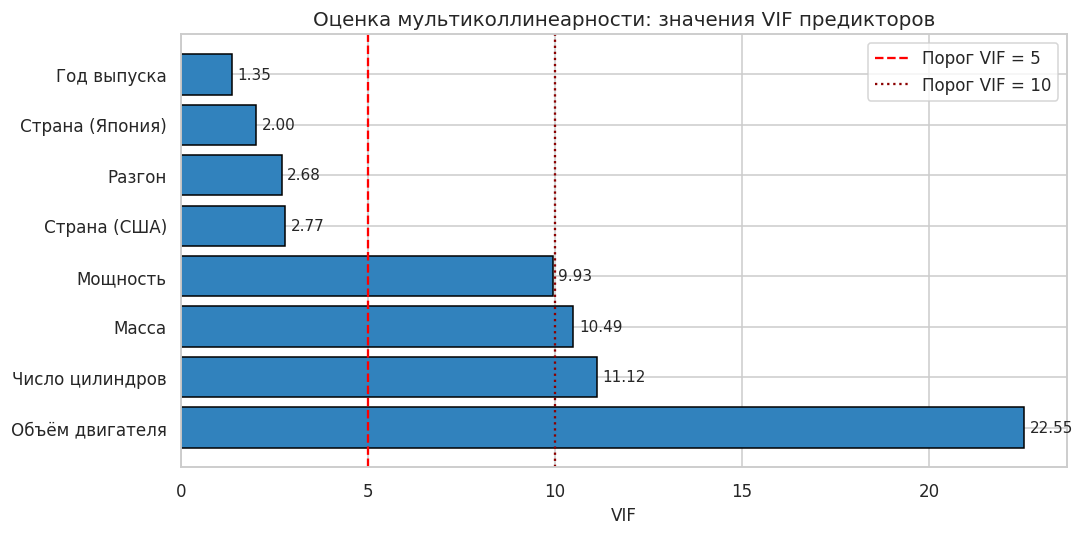

In [7]:
vif_df = pd.DataFrame({
    "Признак": feature_names,
    "VIF (стандартизированные)": [
        variance_inflation_factor(X_train_scaled.values, i)
        for i in range(X_train_scaled.shape[1])
    ],
}).sort_values("VIF (стандартизированные)", ascending=False)

print("Таблица коэффициентов вздутия дисперсии (VIF):")
print(vif_df.round(3).to_string(index=False))

plt.figure(figsize=(10, 5))
bars = plt.barh(vif_df["Признак"], vif_df["VIF (стандартизированные)"], color="#3182bd", edgecolor="black")
plt.axvline(5.0, color="red", linestyle="--", linewidth=1.5, label="Порог VIF = 5")
plt.axvline(10.0, color="darkred", linestyle=":", linewidth=1.5, label="Порог VIF = 10")
plt.title("Оценка мультиколлинеарности: значения VIF предикторов")
plt.xlabel("VIF")
for bar in bars:
    val = bar.get_width()
    plt.text(val + 0.15, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()


### Пояснение к мультиколлинеарности

- VIF объёма двигателя равен **22,6**, числа цилиндров — **11,1**, массы — **10,5**, мощности — **9,9**. Все четыре превышают или почти достигают порога 10.
- Год выпуска (1,35) и страна (около 2–3) мультиколлинеарности не создают.
- Вывод: коэффициенты при объёме, цилиндрах, массе и мощности в обычной регрессии будут неустойчивы и могут получить знаки, не согласованные с простой корреляцией. Прогноз при этом ещё может быть приемлемым. PCA ниже соберёт этот блок в меньшее число ортогональных компонент.


#### Регрессионные модели на исходных признаках

Оцениваются три модели на стандартизированных признаках:

- линейная регрессия (МНК);
- гребневая регрессия Ridge с alpha = 10;
- регрессия лассо с alpha = 0,1.

Для Ridge оставлен тот же порядок штрафа, что и в типовой постановке лабораторной alpha = 10. Для Lasso alpha = 10 на шкале mpg зануляет все коэффициенты, поэтому взят alpha = 0,1: штраф уже отбирает признаки, но не уничтожает модель. Качество на обучении оценивается 5-фолдовой кросс-валидацией по R^2. Итоговые RMSE, R^2 и MAPE считаются на тесте.


In [8]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models_orig = {
    "Линейная регрессия (OLS)": LinearRegression(),
    "Гребневая регрессия (Ridge, alpha=10)": Ridge(alpha=10.0, random_state=42),
    "Лассо регрессия (Lasso, alpha=0.1)": Lasso(alpha=0.1, random_state=42),
}

results_orig = {}
print("=" * 80)
print("Обучение моделей на исходных стандартизированных признаках")
print("=" * 80)
for name, model in models_orig.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring="r2")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results_orig[name] = {
        "R2_CV_mean": float(cv_scores.mean()),
        "R2_Test": float(r2_score(y_test, y_pred)),
        "RMSE_Test": float(np.sqrt(mean_squared_error(y_test, y_pred))),
        "MAPE_Test": float(mean_absolute_percentage_error(y_test, y_pred) * 100),
        "intercept": float(model.intercept_),
        "coefficients": {col: float(coef) for col, coef in zip(feature_names, model.coef_)},
        "pred": y_pred,
    }
    print(
        f"{name:<42} | R^2(CV): {cv_scores.mean():.4f} | "
        f"R^2(тест): {results_orig[name]['R2_Test']:.4f} | "
        f"RMSE: {results_orig[name]['RMSE_Test']:.3f} mpg | "
        f"MAPE: {results_orig[name]['MAPE_Test']:.2f}%"
    )

weights_df = pd.DataFrame({
    "Признак": feature_names,
    "Линейная регрессия (OLS)": models_orig["Линейная регрессия (OLS)"].coef_,
    "Гребневая регрессия (Ridge)": models_orig["Гребневая регрессия (Ridge, alpha=10)"].coef_,
    "Лассо регрессия (Lasso)": models_orig["Лассо регрессия (Lasso, alpha=0.1)"].coef_,
})
print("\nТаблица весов моделей на стандартизированных признаках:")
print(weights_df.round(3).to_string(index=False))
print(f"\nСвободный член линейной регрессии: {models_orig['Линейная регрессия (OLS)'].intercept_:.3f} mpg")


Обучение моделей на исходных стандартизированных признаках
Линейная регрессия (OLS)                   | R^2(CV): 0.8188 | R^2(тест): 0.7923 | RMSE: 3.256 mpg | MAPE: 12.04%
Гребневая регрессия (Ridge, alpha=10)      | R^2(CV): 0.8182 | R^2(тест): 0.7839 | RMSE: 3.321 mpg | MAPE: 12.03%
Лассо регрессия (Lasso, alpha=0.1)         | R^2(CV): 0.8186 | R^2(тест): 0.7870 | RMSE: 3.298 mpg | MAPE: 12.01%

Таблица весов моделей на стандартизированных признаках:
        Признак  Линейная регрессия (OLS)  Гребневая регрессия (Ridge)  Лассо регрессия (Lasso)
Число цилиндров                    -0.581                       -0.392                   -0.000
Объём двигателя                     1.990                        0.457                    0.000
       Мощность                    -0.826                       -1.054                   -0.426
          Масса                    -5.394                       -4.052                   -4.600
         Разгон                     0.119                     

### Пояснение к моделям на исходных признаках

- Линейная регрессия на тесте: **RMSE = 3,26 mpg**, **R² = 0,792**, **MAPE = 12,0%**. Кросс-валидация даёт R² = 0,819. Переобучения нет.
- Ridge почти совпадает с МНК: R² = 0,784, RMSE = 3,32 mpg. Штраф \(\alpha = 10\) слегка сжимает коэффициенты, но не меняет качество.
- Lasso обнуляет цилиндры, объём двигателя и разгон. На тесте R² = 0,787, RMSE = 3,30 mpg. Для прогноза достаточно массы, года, мощности и страны.
- Коэффициент объёма двигателя у МНК **положительный** (+1,99), хотя простая корреляция с mpg равна −0,81. Это прямой симптом VIF = 22,6: модель перекладывает отрицательный эффект большого двигателя на массу. Ridge почти обнуляет этот артефакт (+0,46), Lasso вычёркивает объём полностью.
- Содержательные устойчивые эффекты: масса около −4…−5 mpg на одно стандартное отклонение, год выпуска около +2,7 mpg, автомобили США ниже европейских примерно на 1 mpg после учёта конструкции.


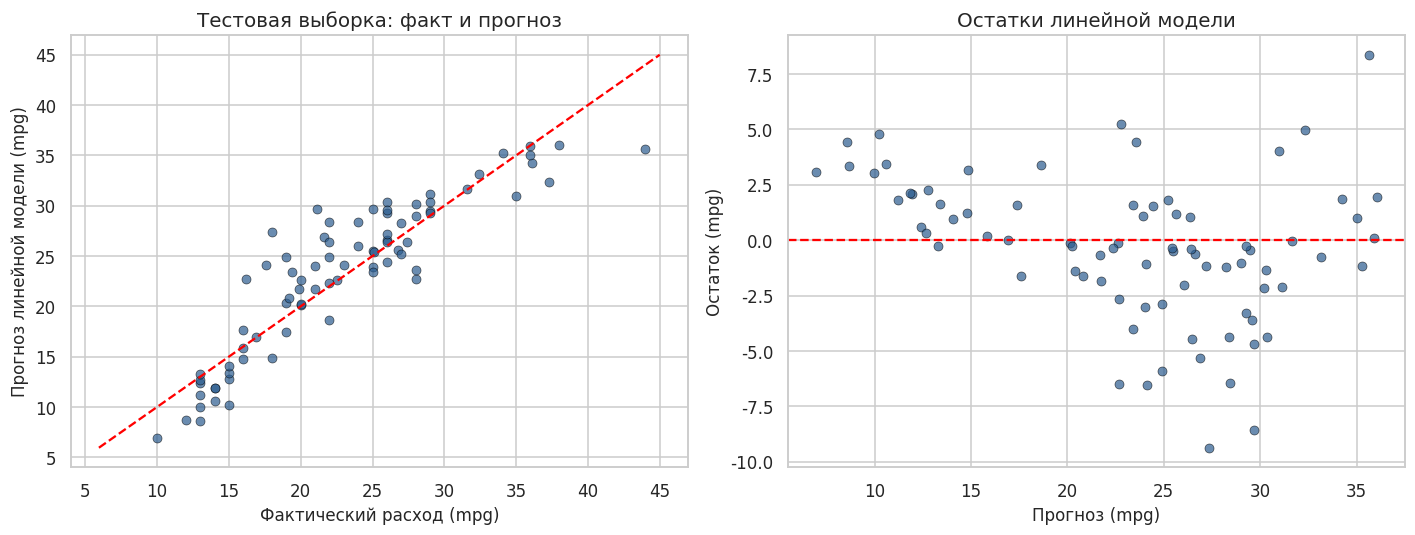

Средний остаток на тесте: -0.348 mpg
Доля |остатка| > 5 mpg: 11.4%


In [9]:
y_pred_ols = results_orig["Линейная регрессия (OLS)"]["pred"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, y_pred_ols, s=35, alpha=0.7, color="#2b5c8f", edgecolor="black", linewidth=0.4)
lims = [min(y_test.min(), y_pred_ols.min()) - 1, max(y_test.max(), y_pred_ols.max()) + 1]
axes[0].plot(lims, lims, color="red", linestyle="--")
axes[0].set_xlabel("Фактический расход (mpg)")
axes[0].set_ylabel("Прогноз линейной модели (mpg)")
axes[0].set_title("Тестовая выборка: факт и прогноз")

resid = y_test.to_numpy() - y_pred_ols
axes[1].scatter(y_pred_ols, resid, s=35, alpha=0.7, color="#2b5c8f", edgecolor="black", linewidth=0.4)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Прогноз (mpg)")
axes[1].set_ylabel("Остаток (mpg)")
axes[1].set_title("Остатки линейной модели")
plt.tight_layout()
plt.show()

print(f"Средний остаток на тесте: {resid.mean():.3f} mpg")
print(f"Доля |остатка| > 5 mpg: {(np.abs(resid) > 5).mean():.1%}")


### Пояснение к прогнозу и остаткам

- Точки ложатся вдоль диагонали. Средний остаток на тесте равен −0,35 mpg: это небольшой сдвиг рядом с RMSE 3,26 mpg. Абсолютная ошибка больше 5 mpg у 11% тестовых автомобилей.
- Ошибка около 3 mpg при среднем 23 mpg согласуется с MAPE 12%. Часть промахов связана с тем, что расход зависит от конструкции не строго линейно, а число цилиндров дискретно.


#### Метод главных компонент

PCA строится по стандартизированной обучающей выборке. Число компонент выбирается по порогу **85% накопленной дисперсии** (как в типовом отчёте по этой лабораторной) и сверяется с критерием Кайзера lambda ge 1.


Результаты факторного анализа (PCA):
Главная компонента  Собственное значение (Lambda)  Доля дисперсии  Накопленная дисперсия
              ГК 1                         4.9149          0.6124                 0.6124
              ГК 2                         1.2138          0.1512                 0.7636
              ГК 3                         0.7832          0.0976                 0.8612
              ГК 4                         0.6095          0.0759                 0.9372
              ГК 5                         0.2873          0.0358                 0.9730
              ГК 6                         0.1241          0.0155                 0.9884
              ГК 7                         0.0602          0.0075                 0.9959
              ГК 8                         0.0327          0.0041                 1.0000

Критерий Кайзера: 2 компоненты, накопленная дисперсия 76.4%
Порог 85% дисперсии: 3 компоненты, накопленная дисперсия 86.1%


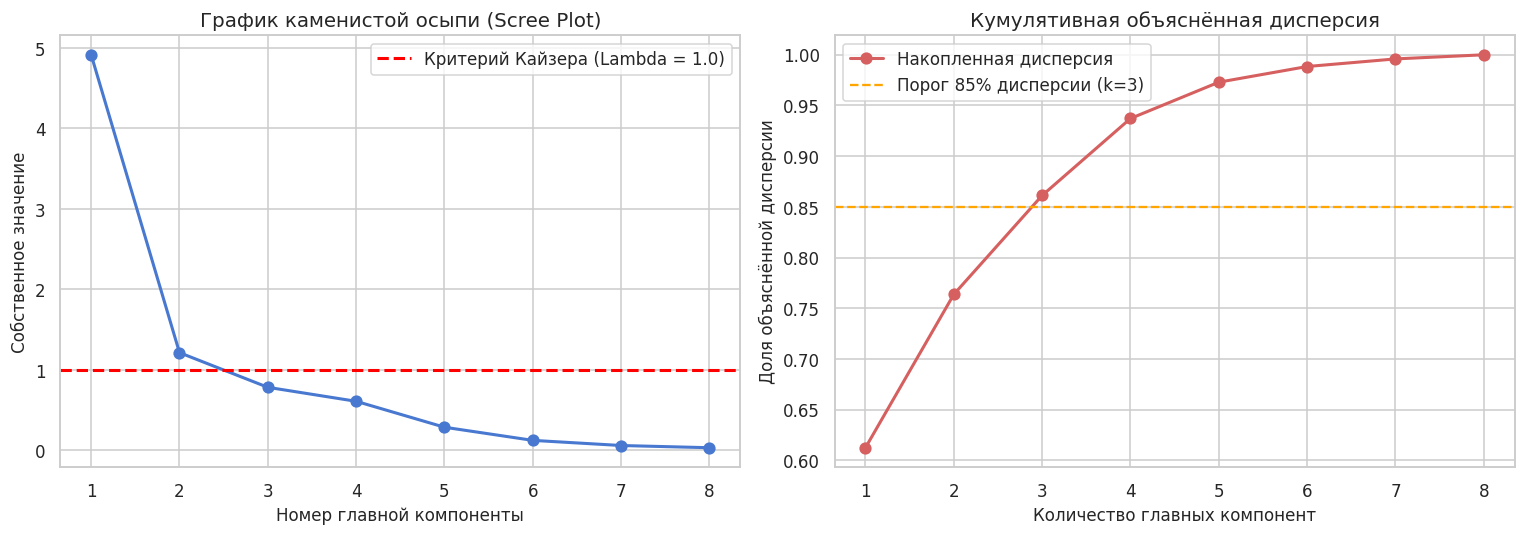

In [10]:
pca_full = PCA().fit(X_train_scaled)
eigenvalues = pca_full.explained_variance_
exp_var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var_ratio)

pca_table = pd.DataFrame({
    "Главная компонента": [f"ГК {i+1}" for i in range(len(eigenvalues))],
    "Собственное значение (Lambda)": eigenvalues,
    "Доля дисперсии": exp_var_ratio,
    "Накопленная дисперсия": cum_var,
})
print("Результаты факторного анализа (PCA):")
print(pca_table.round(4).to_string(index=False))

k_kaiser = int(np.sum(eigenvalues >= 1.0))
k_opt = int(np.argmax(cum_var >= 0.85) + 1)
print(f"\nКритерий Кайзера: {k_kaiser} компоненты, накопленная дисперсия {cum_var[k_kaiser-1]:.1%}")
print(f"Порог 85% дисперсии: {k_opt} компоненты, накопленная дисперсия {cum_var[k_opt-1]:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(eigenvalues) + 1), eigenvalues, "bo-", linewidth=2, markersize=7)
axes[0].axhline(1.0, color="red", linestyle="--", linewidth=2, label="Критерий Кайзера (Lambda = 1.0)")
axes[0].set_title("График каменистой осыпи (Scree Plot)")
axes[0].set_xlabel("Номер главной компоненты")
axes[0].set_ylabel("Собственное значение")
axes[0].legend()

axes[1].plot(range(1, len(cum_var) + 1), cum_var, "ro-", linewidth=2, markersize=7, label="Накопленная дисперсия")
axes[1].axhline(0.85, color="orange", linestyle="--", label=f"Порог 85% дисперсии (k={k_opt})")
axes[1].set_title("Кумулятивная объяснённая дисперсия")
axes[1].set_xlabel("Количество главных компонент")
axes[1].set_ylabel("Доля объяснённой дисперсии")
axes[1].legend()
plt.tight_layout()
plt.show()


### Пояснение к графику каменистой осыпи

- Первая компонента забирает 61,2% дисперсии признаков, вторая — ещё 15,1%. Критерий Кайзера оставляет **2** компоненты (76,4% дисперсии).
- Порог 85% достигается на **3** компонентах (фактически 86,1%). Для повторного обучения моделей берётся \(k = 3\): размерность снижается с 8 до 3, мультиколлинеарный блок двигателя сжимается, и при этом сохраняется больше информации, чем по Кайзеру.


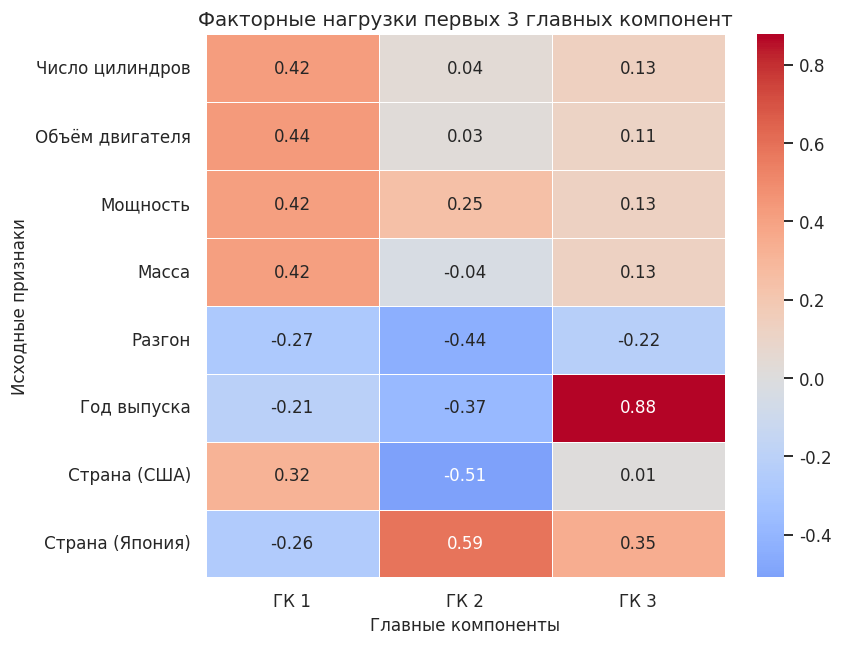

                 ГК 1  ГК 2  ГК 3
Число цилиндров  0.42  0.04  0.13
Объём двигателя  0.44  0.03  0.11
Мощность         0.42  0.25  0.13
Масса            0.42 -0.04  0.13
Разгон          -0.27 -0.44 -0.22
Год выпуска     -0.21 -0.37  0.88
Страна (США)     0.32 -0.51  0.01
Страна (Япония) -0.26  0.59  0.35


In [11]:
pca_opt = PCA(n_components=k_opt).fit(X_train_scaled)
pca_feature_names = [f"ГК {i+1}" for i in range(k_opt)]
loadings = pd.DataFrame(pca_opt.components_.T, columns=pca_feature_names, index=feature_names)

plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title(f"Факторные нагрузки первых {k_opt} главных компонент")
plt.ylabel("Исходные признаки")
plt.xlabel("Главные компоненты")
plt.tight_layout()
plt.show()

print(loadings.round(2).to_string())


### Пояснение к факторным нагрузкам

- **ГК 1** — размер и мощность автомобиля: высокие положительные нагрузки у объёма (0,44), цилиндров, мощности и массы (все около 0,42). Это тот самый блок, который раздувал VIF.
- **ГК 2** — страна и динамика: Япония (+0,59) против США (−0,51), с вкладом разгона.
- **ГК 3** — год выпуска (0,88): отдельный временной фактор 1970–1982 годов.


In [12]:
X_train_pca = pca_opt.transform(X_train_scaled)
X_test_pca = pca_opt.transform(X_test_scaled)

models_pca = {
    "Линейная регрессия (на ГК)": LinearRegression(),
    "Гребневая регрессия (Ridge на ГК, alpha=10)": Ridge(alpha=10.0, random_state=42),
    "Лассо регрессия (Lasso на ГК, alpha=0.1)": Lasso(alpha=0.1, random_state=42),
}

results_pca = {}
print("=" * 80)
print("Обучение моделей регрессии на главных компонентах")
print("=" * 80)
for name, model in models_pca.items():
    cv_scores = cross_val_score(model, X_train_pca, y_train, cv=kf, scoring="r2")
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)
    results_pca[name] = {
        "R2_CV_mean": float(cv_scores.mean()),
        "R2_Test": float(r2_score(y_test, y_pred)),
        "RMSE_Test": float(np.sqrt(mean_squared_error(y_test, y_pred))),
        "MAPE_Test": float(mean_absolute_percentage_error(y_test, y_pred) * 100),
    }
    print(
        f"{name:<46} | R^2(CV): {cv_scores.mean():.4f} | "
        f"R^2(тест): {results_pca[name]['R2_Test']:.4f} | "
        f"RMSE: {results_pca[name]['RMSE_Test']:.3f} mpg | "
        f"MAPE: {results_pca[name]['MAPE_Test']:.2f}%"
    )


Обучение моделей регрессии на главных компонентах
Линейная регрессия (на ГК)                     | R^2(CV): 0.7746 | R^2(тест): 0.7265 | RMSE: 3.737 mpg | MAPE: 13.28%
Гребневая регрессия (Ridge на ГК, alpha=10)    | R^2(CV): 0.7746 | R^2(тест): 0.7290 | RMSE: 3.719 mpg | MAPE: 13.17%
Лассо регрессия (Lasso на ГК, alpha=0.1)       | R^2(CV): 0.7743 | R^2(тест): 0.7279 | RMSE: 3.726 mpg | MAPE: 13.09%


### Пояснение к моделям на главных компонентах

- На трёх компонентах линейная модель даёт **RMSE = 3,74 mpg**, **R² = 0,727**, **MAPE = 13,3%**. Ridge повторяет эти цифры. Lasso чуть хуже по абсолютной ошибке, но того же порядка.
- Компоненты ортогональны, поэтому Ridge больше не меняет решение. Качество ниже, чем на исходных 8 признаках: три компоненты сохраняют 86% дисперсии *признаков*, но отбрасывают часть дисперсии, полезной именно для mpg.


Итоговая сравнительная таблица всех моделей:
                                     Модель           Пространство признаков  R^2 (кросс-вал.)  R^2 (тест)  RMSE (тест, mpg)  MAPE (тест, %)
                   Линейная регрессия (OLS) Исходные стандартизированные (8)            0.8188      0.7923            3.2561         12.0395
      Гребневая регрессия (Ridge, alpha=10) Исходные стандартизированные (8)            0.8182      0.7839            3.3210         12.0306
         Лассо регрессия (Lasso, alpha=0.1) Исходные стандартизированные (8)            0.8186      0.7870            3.2975         12.0085
                 Линейная регрессия (на ГК)           Главные компоненты (3)            0.7746      0.7265            3.7365         13.2789
Гребневая регрессия (Ridge на ГК, alpha=10)           Главные компоненты (3)            0.7746      0.7290            3.7194         13.1700
   Лассо регрессия (Lasso на ГК, alpha=0.1)           Главные компоненты (3)            0.7743      0.7279   

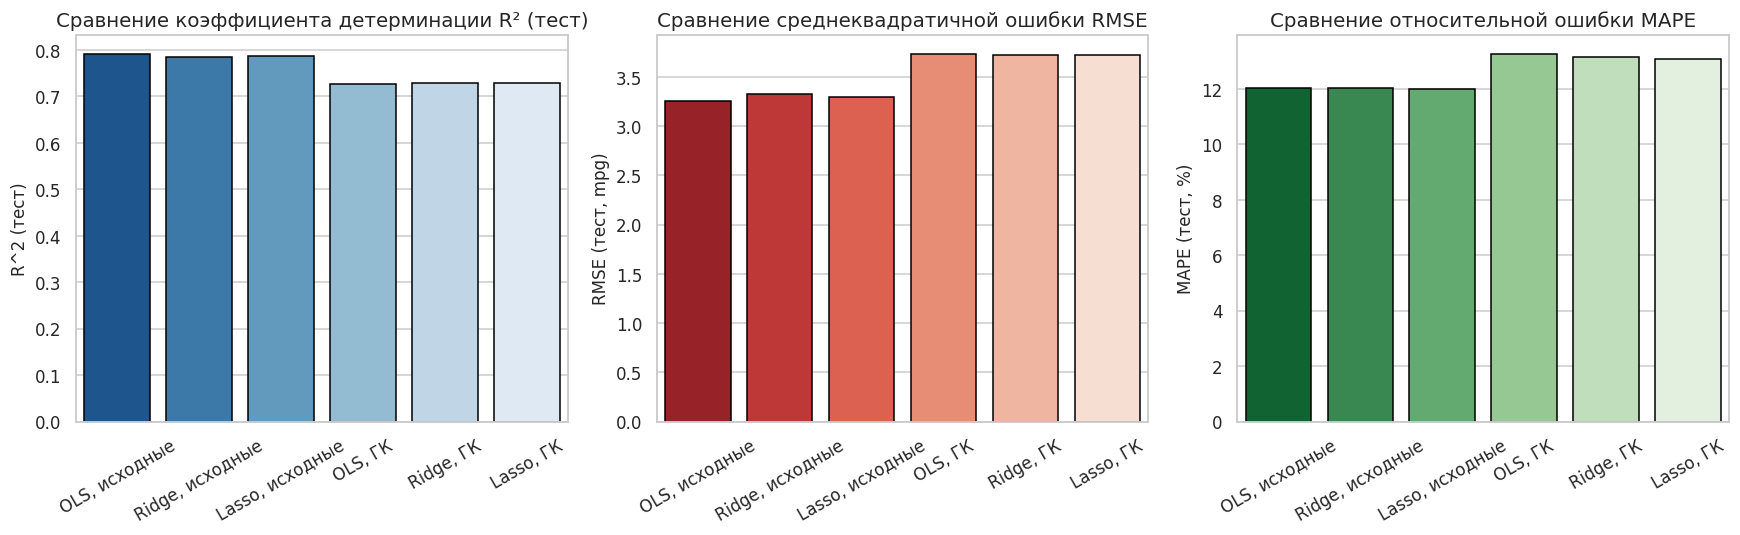

In [13]:
summary_rows = []
for name, res in results_orig.items():
    summary_rows.append({
        "Модель": name,
        "Пространство признаков": f"Исходные стандартизированные ({len(feature_names)})",
        "R^2 (кросс-вал.)": res["R2_CV_mean"],
        "R^2 (тест)": res["R2_Test"],
        "RMSE (тест, mpg)": res["RMSE_Test"],
        "MAPE (тест, %)": res["MAPE_Test"],
    })
for name, res in results_pca.items():
    summary_rows.append({
        "Модель": name,
        "Пространство признаков": f"Главные компоненты ({k_opt})",
        "R^2 (кросс-вал.)": res["R2_CV_mean"],
        "R^2 (тест)": res["R2_Test"],
        "RMSE (тест, mpg)": res["RMSE_Test"],
        "MAPE (тест, %)": res["MAPE_Test"],
    })

summary_df = pd.DataFrame(summary_rows)
print("Итоговая сравнительная таблица всех моделей:")
print(summary_df.round(4).to_string(index=False))

plot_df = summary_df.copy()
plot_df["Кратко"] = [
    "OLS, исходные", "Ridge, исходные", "Lasso, исходные",
    "OLS, ГК", "Ridge, ГК", "Lasso, ГК",
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.barplot(data=plot_df, x="Кратко", y="R^2 (тест)", ax=axes[0], hue="Кратко", palette="Blues_r", edgecolor="black", legend=False)
axes[0].set_title("Сравнение коэффициента детерминации R² (тест)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=plot_df, x="Кратко", y="RMSE (тест, mpg)", ax=axes[1], hue="Кратко", palette="Reds_r", edgecolor="black", legend=False)
axes[1].set_title("Сравнение среднеквадратичной ошибки RMSE")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=plot_df, x="Кратко", y="MAPE (тест, %)", ax=axes[2], hue="Кратко", palette="Greens_r", edgecolor="black", legend=False)
axes[2].set_title("Сравнение относительной ошибки MAPE")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


### Сравнение метрик до и после PCA

| Модель | Признаки | RMSE, mpg | R² | MAPE, % |
| --- | --- | ---: | ---: | ---: |
| Линейная | 8 исходных | 3,26 | 0,792 | 12,04 |
| Ridge, α=10 | 8 исходных | 3,32 | 0,784 | 12,03 |
| Lasso, α=0,1 | 8 исходных | 3,30 | 0,787 | 12,01 |
| Линейная | 3 главные компоненты | 3,74 | 0,727 | 13,28 |
| Ridge, α=10 | 3 главные компоненты | 3,72 | 0,729 | 13,17 |
| Lasso, α=0,1 | 3 главные компоненты | 3,73 | 0,728 | 13,09 |

Лучший прогноз даёт обычная линейная регрессия на исходных признаках. PCA устраняет мультиколлинеарность и сокращает размерность, но увеличивает RMSE примерно на 0,5 mpg и снижает R² на 0,06. Регуляризация почти не улучшает тест: запас точности здесь в составе признаков, а не в разбросе коэффициентов.


### 5) Заключение

По данным Auto MPG линейная регрессия предсказывает топливную экономичность с тестовой ошибкой **3,26 mpg** (RMSE), объясняет **79,2%** дисперсии (R²) и ошибается в среднем на **12%** от фактического mpg (MAPE). Ridge и Lasso дают почти те же цифры. Lasso при alpha = 0,1 оставляет массу, год, мощность и страну — этого достаточно для прогноза.

Мультиколлинеарность в исходной матрице сильная и содержательная: объём двигателя, цилиндры, мощность и масса описывают один размер автомобиля (VIF до 22,6). Из-за этого МНК даёт положительный коэффициент при объёме двигателя, хотя корреляция с mpg отрицательная. Три главные компоненты (86% дисперсии признаков) собирают этот блок в ГК 1, страну — в ГК 2, год — в ГК 3. VIF компонент равен 1, но прогноз слабее: RMSE 3,74 mpg, R² 0,727.

Для интерпретации коэффициентов PCA полезен. Для точности на этой выборке лучше исходная линейная модель, при необходимости — Lasso, который сам вычёркивает дублирующие характеристики двигателя.
